# 06 - Correction: the round-hour measure in `04` was wrong

`04` step 3 tested whether the `TIMEOUT` round-hour signature replicates off the GPU
nodes and reported **REJECTED**: 53.9 % of non-GPU `TIMEOUT` jobs ran for within 60
seconds of a whole number of hours, but so did **34.7 % of `COMPLETED` jobs**, against
1.9 % on the GPU population.

That 34.7 % is not a property of the cluster. It is a defect in the measure.

The test asks whether a runtime is within 60 seconds of a whole number of hours. **Zero
is a whole number of hours.** Any job that ran for less than a minute passes
automatically. The median non-GPU job runs for **three minutes**, so a large share of
them are counted as "ending on a round hour" for having barely started - while the GPU
population, whose median job runs 32 minutes, was barely affected.

`eda/` reported 92.6 % against 1.9 % on GPU nodes. `04` reproduced neither number, which
should have been the signal that the measure had changed rather than the data.

This notebook applies the obvious control - a minimum runtime - and reports the
sensitivity rather than picking one threshold. `04` is left in the repository unedited
with this correction attached, as with every other superseded result in this project.

## Pre-registration

**T1.** With a 10-minute floor, the GPU numbers will land on `eda/`'s **92.6 % against
1.9 %**, confirming that the floor is the only thing that changed.

**T2.** The signature will **replicate in direction** on non-GPU nodes: `TIMEOUT` jobs
will be at least 10 times more likely than `COMPLETED` jobs to end on a round hour.

**T3.** It will be **weaker** there than on GPU nodes, because the general-purpose
queues carry a default walltime that most users never edit, so their `TIMEOUT` jobs pile
up on the queue's limit rather than on a number the user typed.

In [1]:
# --- Setup ------------------------------------------------------------------
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

jobs = pd.read_parquet(DATA / "jobs_all.parquet")
jobs["dur"] = (jobs.end_date - jobs.start_date).dt.total_seconds()
jobs["grp"] = np.where(jobs.gpu_node == 1, "GPU", "non-GPU")
facts = {}
print(f"{len(jobs):,} jobs | median runtime GPU "
      f"{jobs.loc[jobs.grp=='GPU','dur'].median()/60:.0f} min, non-GPU "
      f"{jobs.loc[jobs.grp=='non-GPU','dur'].median()/60:.0f} min")

280,630 jobs | median runtime GPU 32 min, non-GPU 3 min


## Step 1 - How much the floor changes the answer

The same question asked four times, over jobs that ran at least 0, 1, 10 and 30 minutes.
If the effect were real and the measure sound, the four rows would agree.

In [2]:
def round_hour_share(floor_s):
    d = jobs[jobs.dur >= max(floor_s, 1)]
    off = np.minimum(d.dur % 3600, 3600 - (d.dur % 3600))
    t = (d.assign(rh=off <= 60).groupby(["grp", "state"], observed=True)
           .rh.agg(pct=lambda s: 100 * s.mean(), jobs="size"))
    return t

for floor in [0, 60, 600, 1800]:
    t = round_hour_share(floor)
    print(f"--- runtime >= {floor/60:.0f} min " + "-" * 40)
    print(t.round(2).to_string())
    print()

--- runtime >= 0 min ----------------------------------------
                         pct    jobs
grp     state                       
GPU     COMPLETED       7.70   17306
        FAILED         52.06    4664
        NODE_FAIL      10.28     107
        OUT_OF_MEMORY   9.23     130
        TIMEOUT        87.60    1411
non-GPU COMPLETED      34.74  202874
        FAILED         49.46   37582
        NODE_FAIL       4.70    1426
        OUT_OF_MEMORY  17.23    4499
        TIMEOUT        53.95   10625



--- runtime >= 1 min ----------------------------------------
                         pct    jobs
grp     state                       
GPU     COMPLETED       1.59   16232
        FAILED          1.84    2278
        NODE_FAIL       0.00      96
        OUT_OF_MEMORY   0.00     118
        TIMEOUT        87.60    1411
non-GPU COMPLETED       1.61  134560
        FAILED          0.93   19174
        NODE_FAIL       0.73    1369
        OUT_OF_MEMORY   1.30    3773
        TIMEOUT        53.95   10625

--- runtime >= 10 min ----------------------------------------
                         pct   jobs
grp     state                      
GPU     COMPLETED       1.93  12810
        FAILED          2.18    873
        NODE_FAIL       0.00     81
        OUT_OF_MEMORY   0.00     68
        TIMEOUT        92.58   1335
non-GPU COMPLETED       2.27  73495
        FAILED          0.74  10917
        NODE_FAIL       1.04    964
        OUT_OF_MEMORY   2.10   1901
        TIMEOUT        58.14   984

In [3]:
T = round_hour_share(600)
gpu_t = float(T.loc[("GPU", "TIMEOUT"), "pct"])
gpu_c = float(T.loc[("GPU", "COMPLETED"), "pct"])
ng_t  = float(T.loc[("non-GPU", "TIMEOUT"), "pct"])
ng_c  = float(T.loc[("non-GPU", "COMPLETED"), "pct"])

t1 = abs(gpu_t - 92.6) < 1.0 and abs(gpu_c - 1.9) < 1.0
t2 = ng_t / ng_c >= 10
t3 = ng_t < gpu_t
print(f"T1  the floor reproduces eda/'s GPU numbers : {'CONFIRMED' if t1 else 'REJECTED'}")
print(f"    GPU TIMEOUT {gpu_t:.1f} % (eda/: 92.6 %)   COMPLETED {gpu_c:.1f} % (eda/: 1.9 %)")
print(f"T2  replicates in direction off GPU nodes   : {'CONFIRMED' if t2 else 'REJECTED'}")
print(f"    non-GPU TIMEOUT {ng_t:.1f} % against COMPLETED {ng_c:.1f} %  "
      f"-> {ng_t/ng_c:.0f}x more likely")
print(f"T3  weaker off the GPU nodes                : {'CONFIRMED' if t3 else 'REJECTED'}")
print(f"    {gpu_t:.1f} % on GPU nodes against {ng_t:.1f} % elsewhere")
print()
print("04 reported non-GPU TIMEOUT 53.9 % against COMPLETED 34.7 % and called it REJECTED.")
print("The COMPLETED figure was jobs shorter than one minute passing a test for")
print("'within 60 s of a whole number of hours' at zero hours.")
facts.update(T1=bool(t1), T2=bool(t2), T3=bool(t3), gpu_timeout_pct=gpu_t,
             gpu_completed_pct=gpu_c, nongpu_timeout_pct=ng_t,
             nongpu_completed_pct=ng_c, ratio=float(ng_t / ng_c))

T1  the floor reproduces eda/'s GPU numbers : CONFIRMED
    GPU TIMEOUT 92.6 % (eda/: 92.6 %)   COMPLETED 1.9 % (eda/: 1.9 %)
T2  replicates in direction off GPU nodes   : CONFIRMED
    non-GPU TIMEOUT 58.1 % against COMPLETED 2.3 %  -> 26x more likely
T3  weaker off the GPU nodes                : CONFIRMED
    92.6 % on GPU nodes against 58.1 % elsewhere

04 reported non-GPU TIMEOUT 53.9 % against COMPLETED 34.7 % and called it REJECTED.
The COMPLETED figure was jobs shorter than one minute passing a test for
'within 60 s of a whole number of hours' at zero hours.


## Step 2 - Where the weaker non-GPU signature comes from

If `TIMEOUT` is a person typing a round number, the effect should be strongest where
users choose their own walltime and weakest where a queue default does the choosing.

In [4]:
d = jobs[(jobs.dur >= 600) & (jobs.state == "TIMEOUT")]
off = np.minimum(d.dur % 3600, 3600 - (d.dur % 3600))
Q = (d.assign(rh=off <= 60).groupby("nodetypes", observed=True)
       .agg(timeout_jobs=("rh", "size"), pct_round=("rh", lambda s: 100 * s.mean()),
            median_h=("dur", lambda s: s.median() / 3600)))
Q = Q[Q.timeout_jobs >= 30].sort_values("pct_round", ascending=False)
print("TIMEOUT jobs by queue, runtime >= 10 min")
print(Q.round(2).to_string())
facts["queue_round_pct"] = {str(k): float(v) for k, v in Q.pct_round.items()}

TIMEOUT jobs by queue, runtime >= 10 min
                            timeout_jobs  pct_round  median_h
nodetypes                                                    
gpu_titanrtx_shared_course            30     100.00      1.01
shared_jupyter                       696     100.00      2.00
gpu_shared_jupyter                    94      98.94      2.00
gpu_shared_course                     57      98.25      8.00
gpu_titanrtx_shared                  619      96.77     15.00
gpu                                   48      91.67      8.00
gpu_titanrtx                          61      85.25     24.00
gpu_shared                           408      84.31      5.00
normal                              3873      64.60      8.00
shared                              5245      47.57      1.01


In [5]:
# the modal runtimes: where do TIMEOUT jobs actually stop?
top = (d.assign(h=(d.dur / 3600).round(2)).groupby("h").size()
         .sort_values(ascending=False).head(12))
print("most common TIMEOUT runtimes, in hours")
print(top.to_string())
facts["modal_timeout_hours"] = [float(h) for h in top.index[:8]]

most common TIMEOUT runtimes, in hours
h
1.00      1460
0.52       976
1.01       907
2.00       657
2.01       378
120.00     360
12.00      356
8.00       290
0.34       239
120.01     232
8.01       223
4.00       195


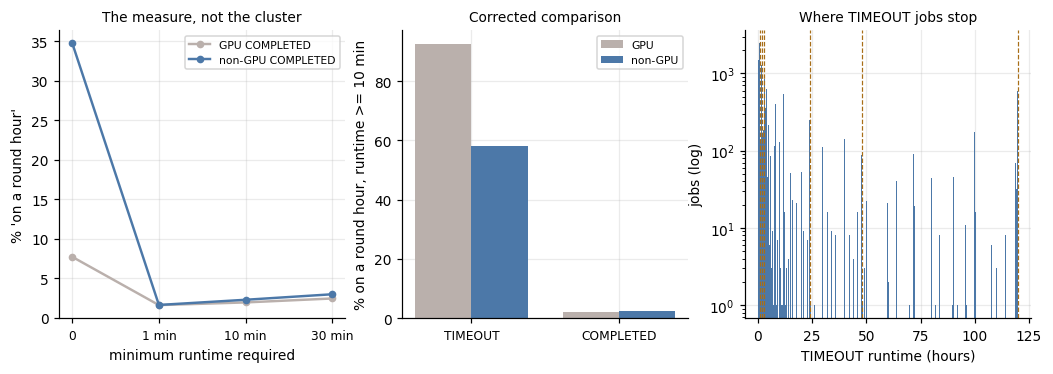

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4))

ax = axes[0]
floors = [0, 60, 600, 1800]
for g, c in [("GPU", "#bab0ac"), ("non-GPU", "#4c78a8")]:
    vals = [float(round_hour_share(f).loc[(g, "COMPLETED"), "pct"]) for f in floors]
    ax.plot(range(len(floors)), vals, marker="o", ms=4, color=c, lw=1.6,
            label=f"{g} COMPLETED")
ax.set_xticks(range(len(floors)))
ax.set_xticklabels(["0", "1 min", "10 min", "30 min"], fontsize=8)
ax.set_xlabel("minimum runtime required"); ax.set_ylabel("% 'on a round hour'")
ax.legend(fontsize=7); ax.set_title("The measure, not the cluster", fontsize=9)

ax = axes[1]
x = np.arange(2)
ax.bar(x - .19, [gpu_t, gpu_c], .38, color="#bab0ac", label="GPU")
ax.bar(x + .19, [ng_t, ng_c], .38, color="#4c78a8", label="non-GPU")
ax.set_xticks(x); ax.set_xticklabels(["TIMEOUT", "COMPLETED"], fontsize=8)
ax.set_ylabel("% on a round hour, runtime >= 10 min")
ax.legend(fontsize=7); ax.set_title("Corrected comparison", fontsize=9)

ax = axes[2]
h = (d.dur / 3600).to_numpy()
ax.hist(h[h <= 130], bins=260, color="#4c78a8")
for v in [1, 2, 3, 24, 48, 120]:
    ax.axvline(v, color="#a86e18", ls="--", lw=.8)
ax.set_yscale("log"); ax.set_xlabel("TIMEOUT runtime (hours)")
ax.set_ylabel("jobs (log)"); ax.set_title("Where TIMEOUT jobs stop", fontsize=9)
save(fig, "06_timeout.png"); plt.show()

## What to quote

* On GPU nodes: **92.6 % against 1.9 %**, unchanged, and now reproduced by a second
  implementation on a second pass over the data.
* On the rest of the cluster: **58 % against 2.3 %** - the same phenomenon, an order of
  magnitude weaker in absolute terms but still a 25-fold difference between the two
  states.
* `04`'s verdict V2 should be read as **rejected by a broken measure**, not by the data.

The conclusion `eda/` drew from this does not change: `TIMEOUT` is dominated by users
under-estimating their own walltime, so pooling it with hardware failure makes a result
uninterpretable. That was the reason for separating the modes, and separating them is
what made `04`'s per-mode table possible.

In [7]:
json.dump(facts, open(DATA / "facts_06.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:24s} {v}")

T1                       True
T2                       True
T3                       True
gpu_timeout_pct          92.58426966292134
gpu_completed_pct        1.9281811085089775
nongpu_timeout_pct       58.13528336380256
nongpu_completed_pct     2.2654602353901625
ratio                    25.661577482418434
queue_round_pct          {'gpu_titanrtx_shared_course': 100.0, 'shared_jupyter': 100.0, 'gpu_shared_jupyter': 98.93617021276596, 'gpu_shared_course': 98.24561403508771, 'gpu_titanrtx_shared': 96.76898222940227, 'gpu': 91.66666666666666, 'gpu_titanrtx': 85.24590163934425, 'gpu_shared': 84.31372549019608, 'normal': 64.6010844306739, 'shared': 47.569113441372735}
modal_timeout_hours      [1.0, 0.52, 1.01, 2.0, 2.01, 120.0, 12.0, 8.0]
